<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
      NLP (Natural Language Processing)
</center></p></h1>

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Libraries
 </font><br>
 <br>   
<br>

In [ ]:

import pandas as pd 
import numpy as np   


import matplotlib.pyplot as plt
import seaborn as sns           


import re              
import string          
import nltk            
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize


nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)



from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  # ارزیابی مدل



from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer
from transformers import  AutoModelForSequenceClassification
from transformers import pipeline

import warnings
warnings.filterwarnings("ignore")  

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [4]:
df1=pd.read_csv(r'D:\Data Analysis- Scientist\Projects\Biga Data,Text Preprocessing & NLP\Transformer- Sentiment-Analysis/validation.csv', header=None)
df1.head()

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [5]:
df1.columns=['Tweet ID','Entity','Sentiment','Tweet Content']

In [6]:
df1.head()

,Tweet ID,Entity,Sentiment,Tweet Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [7]:
df2=pd.read_csv(r'D:\Data Analysis- Scientist\Projects\Biga Data,Text Preprocessing & NLP\Transformer- Sentiment-Analysis/training.csv', header=0)
df2.head()


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [8]:
df2.columns=['Tweet ID','Entity','Sentiment','Tweet Content']

In [9]:
df2.head()

,Tweet ID,Entity,Sentiment,Tweet Content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [10]:
df=pd.concat([df1, df2], ignore_index=True)
df.head()

,Tweet ID,Entity,Sentiment,Tweet Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75681 entries, 0 to 75680
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet ID       75681 non-null  int64 
 1   Entity         75681 non-null  object
 2   Sentiment      75681 non-null  object
 3   Tweet Content  74995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [12]:
df.describe(include= 'object')

,Entity,Sentiment,Tweet Content
count,75681,75681,74995
unique,32,4,69973
top,TomClancysRainbowSix,Negative,
freq,2435,22808,172


In [13]:
df.shape

(75681, 4)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [14]:
df.value_counts()

Tweet ID  Entity         Sentiment   Tweet Content                                                                                                                                                                 
3263      Facebook       Positive    Wow                                                                                                                                                                               6
4050      CS-GO          Positive    Wow                                                                                                                                                                               6
3108      Dota2          Negative    wtf                                                                                                                                                                               6
2842      Dota2          Negative    Shit                                                                                                

In [15]:
df["Sentiment"].value_counts()

Sentiment
Negative      22808
Positive      21108
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64

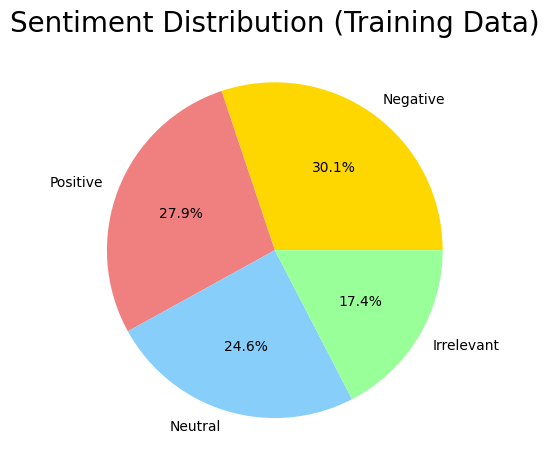

In [24]:
sentiment_counts_train = df['Sentiment'].value_counts()


# Create pie chart for training data
plt.pie(sentiment_counts_train, labels=sentiment_counts_train.index, autopct='%1.1f%%', colors=['gold', 'lightcoral', 'lightskyblue','#99FF99'])
plt.title('Sentiment Distribution (Training Data)', fontsize=20)


# Adjust layout for better visualization
plt.tight_layout()
plt.show()

In [25]:
# Basic statistics
num_users = df['Tweet ID'].nunique()
num_items = df['Sentiment'].nunique()
num_ratings = df['Tweet Content'].nunique()
print(f"Number of unique users: {num_users}")
print(f"Number of unique items: {num_items}")
print(f"Number of unique ratings: {num_ratings}")

Number of unique users: 12447
Number of unique items: 4
Number of unique ratings: 69973


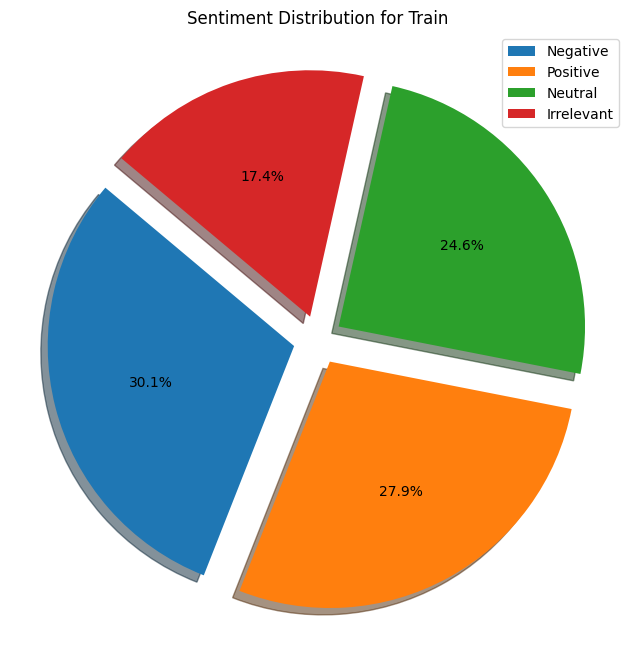

In [26]:
plt.figure(figsize=(8, 8))

explode = [0.1] * len(df['Sentiment'].unique())
plt.pie(df['Sentiment'].value_counts(),
        explode=explode,
        autopct='%1.1f%%',
        shadow=True,
        startangle=140)
plt.legend(labels=['Negative', 'Positive', 'Neutral', 'Irrelevant'])
plt.title('Sentiment Distribution for Train')
plt.axis('off')
plt.show()

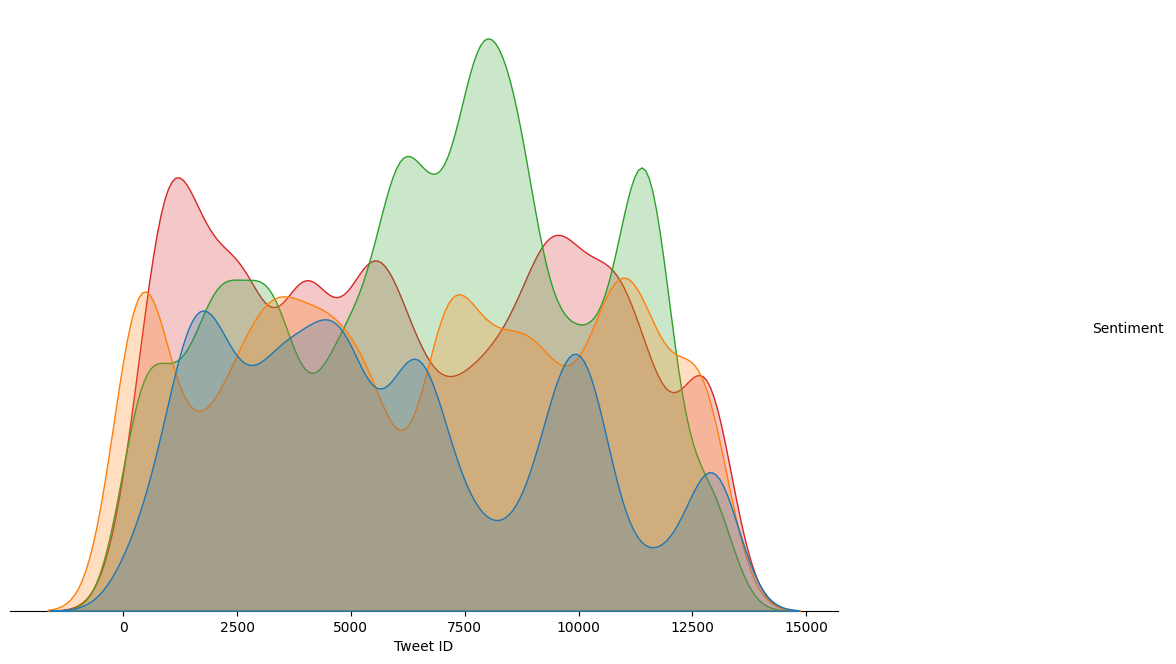

In [27]:
g = sns.pairplot(
    df,
    hue="Sentiment",
    diag_kind="kde",
    corner=True,
    height=2.5
)

g.fig.set_size_inches(12, 8)
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
Missing Value Detection
</center></p></h1>

In [29]:
missing_number = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending=False)

In [12]:
df.duplicated().sum()


3217

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.fillna(0, inplace=True)

In [15]:
df.isnull().sum()

Tweet ID         0
Entity           0
Sentiment        0
Tweet Content    0
dtype: int64

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Text Preprocessing 
</center></p></h1>

In [16]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)


df["clean_text"] = df["Tweet Content"].apply(clean_text)

In [17]:
df["clean_text"]

0        mention facebook struggl motiv go run day tran...
1        bbc news amazon boss jeff bezo reject claim co...
2                      pay word function poorli chromebook
3             csgo matchmak full closet hack truli aw game
4        presid slap american face realli commit unlaw ...
                               ...                        
75676    realiz window partit mac like year behind nvid...
75677    realiz mac window partit year behind nvidia dr...
75678    realiz window partit mac year behind nvidia dr...
75679    realiz window partit mac like year behind nvid...
75680    like window partit mac like year behind driver...
Name: clean_text, Length: 72464, dtype: object

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
       Labeling 
</center></p></h1>

In [ ]:
label_map = {
    "Irrelevant": 0,
    "Neutral": 1,
    "Negative": 2,
    "Positive": 3}

df["label"] = df["Sentiment"].map(label_map)

#  remove irrelevant
df = df.dropna(subset=["label"])

In [19]:
df.head(5)

,Tweet ID,Entity,Sentiment,Tweet Content,clean_text,label
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...,mention facebook struggl motiv go run day tran...,0
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon boss jeff bezo reject claim co...,1
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...,pay word function poorli chromebook,2
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,...",csgo matchmak full closet hack truli aw game,2
4,4433,Google,Neutral,Now the President is slapping Americans in the...,presid slap american face realli commit unlaw ...,1


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
        Feature Engineering
</center></p></h1>

In [20]:
df["final_text"] = df["Entity"] + " " + df["clean_text"]

In [21]:
df.head(5)

,Tweet ID,Entity,Sentiment,Tweet Content,clean_text,label,final_text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...,mention facebook struggl motiv go run day tran...,0,Facebook mention facebook struggl motiv go run...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon boss jeff bezo reject claim co...,1,Amazon bbc news amazon boss jeff bezo reject c...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...,pay word function poorli chromebook,2,Microsoft pay word function poorli chromebook
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,...",csgo matchmak full closet hack truli aw game,2,CS-GO csgo matchmak full closet hack truli aw ...
4,4433,Google,Neutral,Now the President is slapping Americans in the...,presid slap american face realli commit unlaw ...,1,Google presid slap american face realli commit...


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
       Split/Test 
</center></p></h1>





In [22]:
X = df["final_text"]
y = df["label"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [36]:
print(X_train.shape)
print(X_test.shape)

(57971,)
(14493,)


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
transformer (Bert, hugging face)-ML
</center></p></h1>

<blockquote style="margin-right:auto; margin-left:auto; background-color: #FAFAD2; padding: 1em; margin:3px;font-size:20px;font-family:Comic Sans Ms;color:#660000;letter-spacing:0.7px;text-align: justify;">

**BERT: Bidirectional Encoder Representations from Transformers**

BERT is a groundbreaking language model that has significantly advanced the field of Natural Language Processing (NLP).

It stands for Bidirectional Encoder Representations from Transformers.   

**Key Concepts**

- **Bidirectional:** Unlike previous models that processed text sequentially (left to right or right to left), BERT considers the entire context of a word, both preceding and following it. This enables a deeper understanding of language nuances.   
- **Encoder:** BERT focuses on understanding the input text rather than generating new text. It extracts meaningful representations from the input sequence.   
- **Transformers:** The underlying architecture of BERT is based on the Transformer model, known for its efficiency in handling long sequences and capturing dependencies between words.   

**How BERT Works**

- **Pre-training:** BERT is initially trained on a massive amount of text data (like Wikipedia and BooksCorpus) using two unsupervised tasks:
  - **Masked Language Modeling (MLM):** Randomly masks some words in the input and trains the model to predict the masked words based on the context of surrounding words.   
  - **Next Sentence Prediction (NSP):** Trains the model to predict whether two given sentences are consecutive in the original document.   
- **Fine-tuning:** After pre-training, BERT can be adapted to specific NLP tasks with minimal additional training. This is achieved by adding a task-specific output layer to the pre-trained model.   

**Advantages of BERT**

- **Strong performance:** BERT has achieved state-of-the-art results on a wide range of NLP tasks, including question answering, text classification, named entity recognition, and more.   
- **Efficiency:** Fine-tuning BERT for new tasks is relatively quick and requires less data compared to training models from scratch.
- **Versatility:** BERT can be applied to various NLP problems with minimal modifications.   

**Applications of BERT**

- **Search engines:** Improving search relevance and understanding user queries.   
- **Chatbots:** Enhancing natural language understanding and generating more human-like responses.
- **Sentiment analysis:** Accurately determining the sentiment expressed in text.   
- **Machine translation:** Improving the quality of translated text.
- **Text summarization:** Generating concise summaries of lengthy documents.

In essence, BERT is a powerful language model that has revolutionized NLP by capturing the bidirectional context of words and enabling efficient transfer learning for various tasks.   


<blockquote style="margin-right:auto; margin-left:auto; background-color: #FAFAD2; padding: 1em; margin:3px;font-size:20px;font-family:Comic Sans Ms;color:#660000;letter-spacing:0.7px;text-align: justify;">

**DistilBERT: A Smaller, Faster BERT**

DistilBERT is a smaller and faster version of the BERT model. It's created using a technique called knowledge distillation. This means that a smaller model (the student) learns to mimic the behavior of a larger, more complex model (the teacher). In this case, the teacher is BERT.   

**Key Features**

- **Smaller size:** DistilBERT is about 40% smaller than BERT, making it more efficient in terms of memory and computation.   
- **Faster:** It's also significantly faster than BERT, making it suitable for real-time applications.   
- **Comparable performance:** Despite its smaller size, DistilBERT retains about 95% of BERT's language understanding capabilities.   

**How it Works**

- **Knowledge Distillation:** The process involves training DistilBERT to predict the same outputs as BERT for a given input. However, instead of using hard labels (the correct answer), DistilBERT is trained on softened outputs from BERT. This allows the smaller model to learn more generalizable knowledge.   
- **Architecture Simplification:** Some architectural elements of BERT, such as the token type embeddings, are removed to reduce complexity.

**Advantages**

- **Efficiency:** Smaller size and faster inference speed make it suitable for resource-constrained environments.   
- **Cost-effective:** Lower computational requirements lead to reduced training and inference costs.
- **Good performance:** Despite its smaller size, it maintains a high level of performance on various NLP tasks.  

**Applications**

- **Text classification:** Sentiment analysis, topic modeling
- **Named entity recognition:** Identifying entities in text (e.g., persons, organizations, locations)
- **Question answering:** Finding answers to questions based on given text
- **Text generation:** Summarization, translation

In summary, DistilBERT offers a compelling balance between model size, speed, and performance. It's a valuable tool for NLP practitioners looking to deploy models efficiently without sacrificing accuracy. 

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
Tokenization & Transformation Vectors to Matrices 
</center></p></h1>

In [24]:
model_name1 = "bert-base-uncased"   #bert
model_name2 = "distilbert-base-uncased"  #distilbert
model_name3 = "albert-base-v2"  #albert

In [25]:


# -------------------- Tokenizer (Pretrained) --------------------

tokenizer = AutoTokenizer.from_pretrained(model_name1)


# -------------------- encoding --------------------


train_enc = tokenizer(list(X_train), padding=True, truncation=True, max_length=128, return_tensors="tf")
test_enc  = tokenizer(list(X_test),  padding=True, truncation=True, max_length=128, return_tensors="tf")

In [52]:
# convert to numpy array

train_ids = np.array(train_enc["input_ids"])
test_ids  = np.array(test_enc["input_ids"])

print("train shape:", train_ids.shape)
print("test shape :", test_ids.shape)

train shape: (57971, 128)
test shape : (14493, 128)


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
 Dataset
</center></p></h1>

In [26]:
# --------------------  TF Dataset --------------------
train_dataset = tf.data.Dataset.from_tensor_slices(
    (dict(train_enc), y_train)
).shuffle(1000).batch(16)



test_dataset = tf.data.Dataset.from_tensor_slices(
    (dict(test_enc), y_test)
).batch(16)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
Model (Pretrained Transformer)
</center></p></h1>

# 1 Tensorflow 

In [3]:

from transformers import TFAutoModelForSequenceClassification
# ===========================


In [32]:
num_labels=4


model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=4
)

#num_labels = number of classes in your dataset
#epochs = how many times model sees all data


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
Model Fiting
</center></p></h1>

In [ ]:
import tensorflow as tf


from tf_keras.optimizers import Adam
from tf_keras.losses import SparseCategoricalCrossentropy

optimizer = Adam(learning_rate=5e-5)

model.compile(
    optimizer=optimizer,
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

In [35]:

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3


  15/3624 [..............................] - ETA: 10:55:40 - loss: 1.3838 - accuracy: 0.2833

KeyboardInterrupt: 

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
Predict 
</center></p></h1>

In [ ]:
# src/evaluate.py


def evaluate(model, dataset):

    preds = model.predict(dataset).logits
    y_pred = np.argmax(preds, axis=1)

    y_true = []
    for _, y in dataset:
        y_true.extend(y.numpy())

    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred))

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Eval Function


      
</center></p></h1>

In [ ]:
model_loss = pd.DataFrame(model.history.history)
model_loss.head()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive', 'Irrelevant']
))

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
